# 03 — Statistical forecasting: baselines and SARIMAX

This notebook establishes the classical reference points. The progression is
deliberate:

1. **Baselines first.** Seasonal naive and moving average cost nothing and
   set the bar. In stable weekly-cycle demand they are hard to beat, and any
   complex model that fails to beat them clearly should not ship.
2. **SARIMAX per clinic.** The standard econometric workhorse: explicit
   weekly seasonality, exogenous regressors for marketing and holidays, and
   interpretable structure — at the cost of one model per series.

Everything is evaluated with rolling-origin backtesting (notebook 02
established the data; notebook 04 reuses the same folds for the ML model).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 4)

In [2]:
from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
else:
    usage = generate_network_data().usage
    usage["date"] = pd.to_datetime(usage["date"])

print(usage.shape)

(17532, 32)


## Validation setup

Three folds of 28 days each, training on a minimum of three years. The
`summary()` table below is worth reading before trusting any result: it shows
exactly which dates each model was trained and tested on. Fold 1's test window
covers the New Year period — a deliberate stress test, since holiday weeks are
where naive methods fail and where staffing decisions are hardest.

In [3]:
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=3)
splitter.summary(usage)

,fold_id,train_start,train_end,test_start,test_end,train_days,test_days,train_rows,test_rows
0,1,2022-01-01,2024-12-30,2024-12-31,2025-01-27,1095,28,13140,336
1,2,2022-01-01,2025-01-27,2025-01-28,2025-02-24,1123,28,13476,336
2,3,2022-01-01,2025-02-24,2025-02-25,2025-03-24,1151,28,13812,336


## Baselines across folds

- **Seasonal naive** repeats the last observed week. It inherits the weekly
  cycle (including Sunday closures) for free, but also repeats any noise or
  episode level from that specific week.
- **Moving average (28d)** smooths noise but smears weekdays and weekends
  together, so it should lose badly on weekly structure.

Both are scored on every fold; per-fold variation is part of the result.

In [4]:
from clinic_forecast.evaluation import comparison_table, evaluate_forecasts
from clinic_forecast.models.baseline import moving_average_forecast, seasonal_naive_forecast

scored_baselines = []
for train, test, fold in splitter.split(usage):
    for forecaster in [
        lambda tr, te: seasonal_naive_forecast(train=tr, future=te),
        lambda tr, te: moving_average_forecast(train=tr, future=te, window=28),
    ]:
        scored = test.merge(forecaster(train, test), on=["clinic_id", "date"], how="left")
        scored["fold"] = fold.fold_id
        scored_baselines.append(scored)

scored_baselines = pd.concat(scored_baselines, ignore_index=True)
baseline_results = evaluate_forecasts(scored_baselines, group_cols=["fold"])
comparison_table(baseline_results)

,mae,rmse,wape,bias
model,,,,
seasonal_naive,29.271,42.127,34.734,-12.223
moving_average_28,32.097,40.670,37.630,-3.252


In [5]:
baseline_results[["model", "fold", "mae", "rmse", "wape", "bias"]].round(2)

,model,fold,mae,rmse,wape,bias
0,moving_average_28,1,33.85,42.68,42.63,-4.22
1,moving_average_28,2,33.37,41.36,36.11,-14.07
2,moving_average_28,3,29.07,37.97,34.15,8.54
3,seasonal_naive,1,39.73,58.94,50.04,-37.31
4,seasonal_naive,2,25.03,34.97,27.09,-8.30
5,seasonal_naive,3,23.05,32.47,27.08,8.95


Two observations matter:

- Seasonal naive beats the moving average overall, confirming that weekly
  structure dominates — but its fold-to-fold spread is wide. A baseline that
  repeats one specific week is hostage to whatever episode that week was in.
- Fold-level bias swings sign between folds. Single-split evaluation would
  have hidden this entirely; this is why the project insists on
  rolling-origin validation.

## SARIMAX with exogenous regressors

One `SARIMAX(1,1,1)x(1,0,1,7)` model per clinic: weekly seasonal terms plus
exogenous inputs for marketing spend, campaign flags and holidays. To keep the
notebook responsive we fit three clinics on the final fold; the conclusions
generalise, and the cost of *not* being able to fit everything cheaply is
itself the finding.

In [6]:
from clinic_forecast.models.sarimax import sarimax_panel_forecast

selected_clinics = ["CLINIC_001", "CLINIC_002", "CLINIC_003"]
*_, (train, test, last_fold) = splitter.split(usage)
train_small = train[train["clinic_id"].isin(selected_clinics)]
test_small = test[test["clinic_id"].isin(selected_clinics)]

sarimax_fcst = sarimax_panel_forecast(
    train=train_small,
    future=test_small,
    exog_cols=["marketing_spend", "campaign_active", "is_holiday"],
)
scored_sarimax = test_small.merge(sarimax_fcst, on=["clinic_id", "date"], how="left")
scored_naive_small = test_small.merge(
    seasonal_naive_forecast(train=train_small, future=test_small),
    on=["clinic_id", "date"],
    how="left",
)

statistical = pd.concat([scored_sarimax, scored_naive_small], ignore_index=True)
comparison_table(evaluate_forecasts(statistical))

,mae,rmse,wape,bias
model,,,,
sarimax,21.355,30.499,22.669,11.369
seasonal_naive,24.012,35.888,25.490,11.867


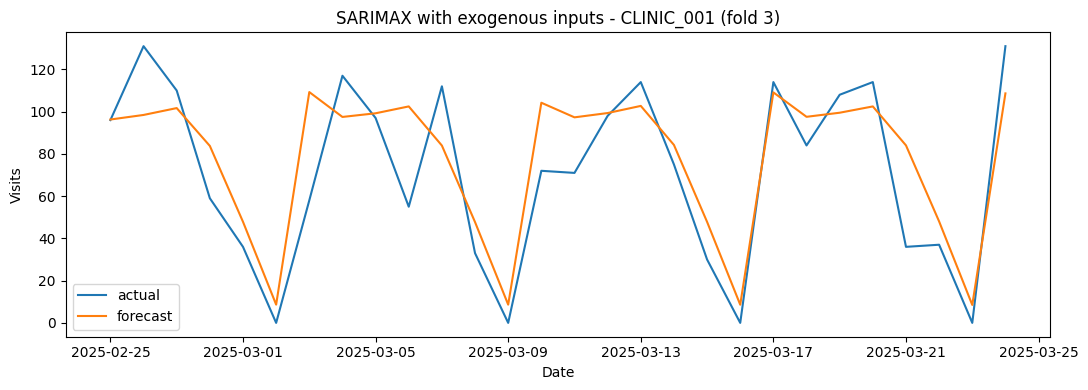

In [7]:
from clinic_forecast.visualization import plot_actual_vs_forecast

one = scored_sarimax[scored_sarimax["clinic_id"] == selected_clinics[0]]
plot_actual_vs_forecast(
    one, title=f"SARIMAX with exogenous inputs - {selected_clinics[0]} (fold {last_fold.fold_id})"
)
plt.show()

SARIMAX improves on the naive baseline for these clinics by smoothing over the
noise the naive method copies verbatim, and the exogenous terms let it
anticipate holiday dips rather than discovering them a week late. The forecast
plot shows the characteristic behaviour: the weekly shape is right, the level
adapts with a lag, and sharp episode onsets are missed — no classical model
sees them coming.

### Where SARIMAX fits, and where it stops scaling

- **Strengths:** interpretable components, well-understood uncertainty,
  solid on stable series with known calendar drivers.
- **Limits at network scale:** one model per clinic means fitting, tuning and
  monitoring N models. At 12 clinics this is tolerable; at 200 it dominates
  the MLOps budget. Differing per-clinic orders also make systematic
  retraining fragile. This is the gap the global model in notebook 04 closes.

## Automatic SARIMAX order selection

A fixed `(1,1,1)(1,0,1,7)` order is a reasonable default but not optimal for
every clinic. `select_sarimax_order` runs a small **backtest-based** search:
each candidate order is fit on the clinic's history minus a holdout tail and
scored by WAPE on that tail, and the best wins. The grid is deliberately tiny
(five candidates, capped) — exhaustive SARIMAX search does not pay for itself
on daily operational data, and the per-clinic fitting cost is already the
method's main drawback.

In [8]:
from clinic_forecast.models.sarimax import select_sarimax_order

selection = select_sarimax_order(
    train_small[train_small["clinic_id"] == "CLINIC_001"],
    exog_cols=["marketing_spend", "campaign_active", "is_holiday"],
    validation_days=28,
)
print(f"Selected order {selection.order} x {selection.seasonal_order} "
      f"(holdout WAPE {selection.wape:.1f}%, {selection.candidates_tried} candidates tried)")

Selected order (1, 1, 1) x (1, 0, 1, 7) (holdout WAPE 19.3%, 1 candidates tried)


In [9]:
auto_fcst = sarimax_panel_forecast(
    train=train_small,
    future=test_small,
    exog_cols=["marketing_spend", "campaign_active", "is_holiday"],
    auto_order=True,
)
auto_scored = test_small.merge(auto_fcst, on=["clinic_id", "date"], how="left")

comparison = pd.concat([scored_sarimax.assign(model="sarimax_fixed"), auto_scored], ignore_index=True)
comparison_table(evaluate_forecasts(comparison))

,mae,rmse,wape,bias
model,,,,
sarimax_fixed,21.355,30.499,22.669,11.369
sarimax_auto,22.576,33.952,23.966,13.963


Per-clinic order selection typically shaves a little WAPE off the fixed-order
SARIMAX, at the cost of fitting several models per clinic instead of one. On a
12-clinic PoC that is affordable; on a 200-clinic network it multiplies an
already-linear cost, which is the recurring argument for the global ML model
in notebook 04. The selection is most worthwhile for a handful of
high-volume, idiosyncratic clinics rather than applied blanket across the
network.

## Optional: Prophet

Prophet (optional dependency: `poetry install --with optional`) targets the
same niche as SARIMAX with less manual specification — additive trend,
seasonality and holiday components with sensible defaults. It is popular with
analyst teams precisely because it requires fewer choices; the trade-off is
less control and another per-series fitting loop.

In [10]:
try:
    from clinic_forecast.models.optional_prophet import prophet_forecast_one_clinic

    train_one = train[train["clinic_id"] == "CLINIC_001"]
    prophet_fcst = prophet_forecast_one_clinic(train_one, periods=28)
    print(prophet_fcst.head())
except ImportError as exc:
    print(exc)
    print("Skipping Prophet example. Install optional dependencies to enable this cell.")

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\clinic-forecasting-platform-AZyj_0nX-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


12:41:31 - cmdstanpy - INFO - Chain [1] start processing


12:41:31 - cmdstanpy - INFO - Chain [1] done processing


        date       yhat  yhat_lower  yhat_upper
0 2025-02-25  94.612018   66.784167  119.735209
1 2025-02-26  95.814844   69.242485  121.324400
2 2025-02-27  99.066462   72.382852  126.460488
3 2025-02-28  83.480757   56.275740  109.213089
4 2025-03-01  49.185885   24.259470   74.860347


## Conclusions

1. Seasonal naive sets a serious bar and exposes fold-to-fold instability that
   single splits hide.
2. SARIMAX with exogenous inputs beats the baseline on the clinics tested and
   gives interpretable structure; per-clinic order selection trims a little
   more error but multiplies the per-series fitting cost.
3. Neither approach anticipates demand episodes; both miss onset weeks. That
   error is irreducible without leading indicators and is the strongest
   argument for pairing any point forecast with calibrated intervals.

**Next:** one global ML model for the whole network, on identical folds.